# Overview

In [27]:
import os
from dotenv import load_dotenv

load_dotenv()

input_path_str: str = os.getenv("FEEDBACK_SOURCE_DIR_PATH") or '.'


In [28]:
# from nltk.sentiment import SentimentIntensityAnalyzer
# import nltk 

# # nltk.download('vader_lexicon')
# sia = SentimentIntensityAnalyzer()

# def nullable_polarity_scores(text):
#     if pd.isna(text):
#         return {"neg": np.nan, "neu": np.nan, "pos": np.nan, "compound": np.nan}
#     return sia.polarity_scores(str(text))

In [29]:
from enum import StrEnum, auto
from pathlib import Path
import pandas as pd

class DataFileType(StrEnum):
    CLEAN = auto()
    ENHANCED = auto()

class DataFilePeriod(StrEnum):
    FIRST_MONTH = '20d'
    HALF_YEAR = '6m'
    FULL_YEAR = '1y'

class InputManager:
    _type: DataFileType
    _period: DataFilePeriod
    _SOURCE_DIR_PATH: Path = Path(input_path_str)
    _SUFFIX: str = '.csv'

    def _create_input_path(self, file_type: DataFileType, data_period: DataFilePeriod) -> Path:
        return (self._SOURCE_DIR_PATH / (file_type + data_period).upper()).with_suffix(self._SUFFIX)

    def get_input_data(self, file_type: DataFileType, data_period: DataFilePeriod) -> pd.DataFrame:
        path: Path = self._create_input_path(file_type, data_period)
        df = pd.read_csv(path, index_col=0)
        return df

inputs: InputManager = InputManager()
preferred_file_type: DataFileType = DataFileType.ENHANCED

In [30]:
from dataclasses import dataclass, field
from typing import Any, Dict, List

@dataclass
class PreprocessingStrategy:
    type_map: Dict[str, Any] = field(default_factory=dict)              # simple dtypes
    datetime_cols: List[str] = field(default_factory=list)
    categorical_cols: List[str] = field(default_factory=list)
    ordinal_cols: Dict[str, List[Any]] = field(default_factory=dict)    # Map column name to an ordered list of categories, lowest to highest

@dataclass
class DataPreprocessor:
    _df: pd.DataFrame

    def set_dtypes(self, strategy: PreprocessingStrategy) -> None:
        df: pd.DataFrame = self._df.copy()

        for col in strategy.datetime_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col])

        for col in strategy.categorical_cols:
            if col in df.columns:
                df[col] = df[col].astype("category")

        for col, categories in strategy.ordinal_cols.items():
            if col in df.columns:
                # Enforce exact order and flag as ordered
                ordinal_type = pd.CategoricalDtype(categories=categories, ordered=True)
                df[col] = df[col].astype(ordinal_type)

        valid_type_map = {col: dtype for col, dtype in strategy.type_map.items() if col in df.columns}
        df = df.astype(valid_type_map)

        self._df = df

In [31]:
current_data_period: DataFilePeriod = DataFilePeriod.FIRST_MONTH

df = inputs.get_input_data(preferred_file_type, current_data_period)
df.insert(0, 'posting_timestamp', df['posting_day'] + ' ' + df['posting_hour'])
df.drop(['posting_day', 'posting_hour'], axis=1, inplace=True)

In [32]:
strategy: PreprocessingStrategy = PreprocessingStrategy(
    type_map={
        'positive_feedback': 'string[pyarrow]', 
        'negative_feedback': 'string[pyarrow]', 
        'positive_feedback_EN': 'string[pyarrow]', 
        'negative_feedback_EN': 'string[pyarrow]',
        'positive_feedback_EN_neg': 'float32',
        'positive_feedback_EN_neu': 'float32',
        'positive_feedback_EN_pos': 'float32',
        'positive_feedback_EN_compound': 'float32',
        'negative_feedback_EN_neg': 'float32',
        'negative_feedback_EN_neu': 'float32',
        'negative_feedback_EN_pos': 'float32',
        'negative_feedback_EN_compound': 'float32',
    },
    datetime_cols=['posting_timestamp'],
    categorical_cols=['survey_type', 'department'],
    ordinal_cols={'onboarding_rating': list(range(1,6))}
)

preprocessor: DataPreprocessor = DataPreprocessor(df)
preprocessor.set_dtypes(strategy)
df = preprocessor._df
df

,posting_timestamp,survey_type,department,onboarding_rating,positive_feedback,negative_feedback,positive_feedback_EN,negative_feedback_EN,positive_feedback_EN_neg,positive_feedback_EN_neu,positive_feedback_EN_pos,positive_feedback_EN_compound,negative_feedback_EN_neg,negative_feedback_EN_neu,negative_feedback_EN_pos,negative_feedback_EN_compound
id,,,,,,,,,,,,,,,,
507,2024-08-24 10:02:00,20 Days,NaN,3,"atmosfera, pomoc innych , przychylność, dostep...",moze brak 1 maila z krokami prostepowania dla ...,"atmosphere, help from others, friendliness, ac...",maybe there is no 1 email with the steps for n...,0.000,0.616,0.384,0.7964,0.180,0.820,0.000,-0.2960
515,2024-08-25 11:42:00,20 Days,NaN,2,Organizacja pracy,Nieczytelna mapa myśli. Uważam że powinna być ...,Work organization,The mind map is unreadable. I think it should ...,0.000,1.000,0.000,0.0000,0.124,0.761,0.115,-0.0609
533,2024-08-26 18:32:00,20 Days,NaN,3,Poziom merytoryczny pozostałych członków,Nie do końca przejrzysty proces onboardingu,The substantive level of the other members,Onboarding process not entirely transparent,0.000,1.000,0.000,0.0000,0.000,1.000,0.000,0.0000
600,2024-10-01 13:00:00,20 Days,NaN,5,Kontakt z ludźmi,na chwilę obecną nie widzę niedogodności,Contact with people,I don't see any inconvenience at the moment,0.000,1.000,0.000,0.0000,0.000,0.740,0.260,0.2755
608,2024-10-01 19:45:00,20 Days,NaN,5,Podobała mi się duża automatyzacja wszystkiego...,Tak właściwie to zabrakło mi takiej odpowiedzi...,I liked the extensive automation of everything...,"Actually, I didn't have an answer for the ques...",0.000,0.862,0.138,0.6800,0.000,0.965,0.035,0.0644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,2026-06-29 18:48:00,20 Days,T,4,"dobrze rozwinięta struktura organizacyjna, i p...",wziąż nie dostałam żadnego konkretnego zadania...,well-developed organizational structure and pr...,I still haven't been given any specific task t...,0.000,1.000,0.000,0.0000,0.000,1.000,0.000,0.0000
2272,2026-06-30 20:07:00,20 Days,O,5,Komunikatywność ze wszystkimi :slightly_smilin...,Nic takiego jeszcze się nie znalazło,Communicative with everyone :slightly_smiling_...,Nothing like this has been found yet,0.000,1.000,0.000,0.0000,0.260,0.740,0.000,-0.2755
2293,2026-07-08 18:33:00,20 Days,O,3,Ciężko jeszcze powiedzieć,<NA>,It's still hard to say,<NA>,0.259,0.741,0.000,-0.1027,NaN,NaN,NaN,NaN


In [33]:
print(df.shape)
print('---\n')
print(df.info())
print('---\n')
print(df.head())
print('---\n')
print('The indicies are unique: ', df.index.nunique() == len(df))

(108, 16)
---

<class 'pandas.DataFrame'>
Index: 108 entries, 507 to 2321
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   posting_timestamp              108 non-null    datetime64[us]
 1   survey_type                    108 non-null    category      
 2   department                     78 non-null     category      
 3   onboarding_rating              108 non-null    category      
 4   positive_feedback              82 non-null     string        
 5   negative_feedback              69 non-null     string        
 6   positive_feedback_EN           82 non-null     string        
 7   negative_feedback_EN           69 non-null     string        
 8   positive_feedback_EN_neg       82 non-null     float32       
 9   positive_feedback_EN_neu       82 non-null     float32       
 10  positive_feedback_EN_pos       82 non-null     float32       
 11  positive_feedback

## Datetime variables

Datetime variables require specialized analysis because time functions both as an index (ordering events sequentially) and a feature (reflecting cyclical human behavior and seasonality).
The main goal of datetime univariate analysis is to evaluate data continuity, spot missing time gaps, assess time resolution, and understand periodic patterns.

### posting_timestamp

In [ ]:
current_series = df['posting_timestamp']
t_min, t_max = current_series.min(), current_series.max()
total_span = (t_max - t_min)
time_deltas = current_series.diff()

def td_format(td_object):
    seconds = int(td_object.total_seconds())
    periods = [
        ('year',        60*60*24*365),
        ('month',       60*60*24*30),
        ('day',         60*60*24),
        ('hour',        60*60),
        ('minute',      60),
        ('second',      1)
    ]

    strings=[]
    for period_name, period_seconds in periods:
        if seconds > period_seconds:
            period_value , seconds = divmod(seconds, period_seconds)
            has_s = 's' if period_value > 1 else ''
            strings.append("%s %s%s" % (period_value, period_name, has_s))

    return " ".join(strings)

print(f'''
Temporal coverage
    t_min: {t_min:%Y/%m/%d}
    t_max: {t_max:%Y/%m/%d}
    total_span: {td_format(total_span)}
---
Sampling Interval & Resolution
    median difference between answer times: {td_format(time_deltas.median())}
    average difference between answer times: {td_format(time_deltas.mean())}
''')


Temporal coverage
    t_min: 2024/08/24
    t_max: 2026/07/18
    total_span: 1 year 10 months 27 days 23 hours 41 minutes
---
Sampling Interval & Resolution
    median difference between answer times: 2 days 4 hours 31 minutes
    average difference between answer times: 6 days 11 hours 26 minutes 10 seconds



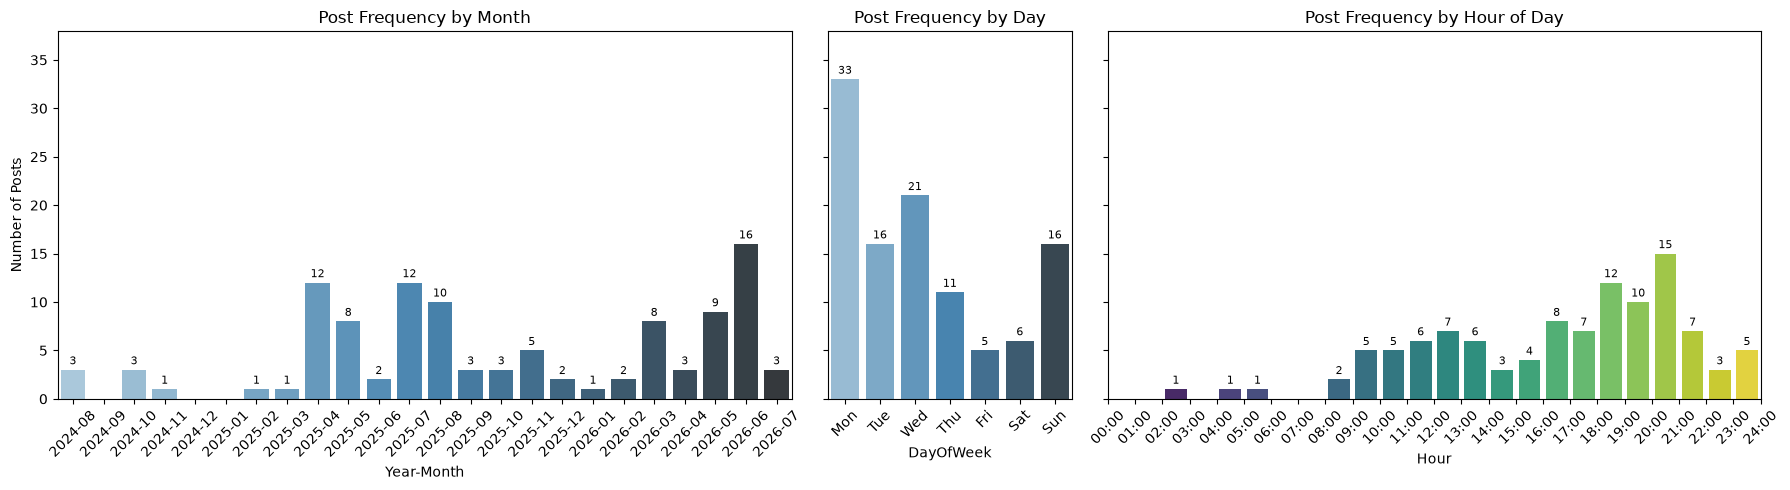

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_datetime = df.dropna(subset=['posting_timestamp']).copy()

df_datetime['Year-Month'] = [ts.strftime('%Y-%m') for ts in df_datetime['posting_timestamp']]
df_datetime['DayOfWeek']  = [ts.strftime('%a') for ts in df_datetime['posting_timestamp']]
df_datetime['Hour']       = [ts.hour for ts in df_datetime['posting_timestamp']]

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

monthly_map = {}
for ym in df_datetime['Year-Month']:
    monthly_map[ym] = monthly_map.get(ym, 0) + 1

if monthly_map:
    min_ym = min(monthly_map.keys())
    max_ym = max(monthly_map.keys())
    
    start_y, start_m = map(int, min_ym.split('-'))
    end_y, end_m     = map(int, max_ym.split('-'))
    
    all_months = []
    curr_y, curr_m = start_y, start_m
    while (curr_y, curr_m) <= (end_y, end_m):
        all_months.append(f"{curr_y:04d}-{curr_m:02d}")
        curr_m += 1
        if curr_m > 12:
            curr_m = 1
            curr_y += 1
            
    monthly_keys = all_months
    monthly_vals = [monthly_map.get(ym, 0) for ym in monthly_keys]
else:
    monthly_keys = []
    monthly_vals = []

daily_map = {}
for d in df_datetime['DayOfWeek']:
    daily_map[d] = daily_map.get(d, 0) + 1

daily_vals = [daily_map.get(d, 0) for d in day_order]

hourly_map = {}
for h in df_datetime['Hour']:
    hourly_map[h] = hourly_map.get(h, 0) + 1

hourly_vals = [hourly_map.get(h, 0) for h in range(24)]

y_max = max(max(monthly_vals, default=0), max(daily_vals, default=0), max(hourly_vals, default=0)) * 1.15

fig, axes = plt.subplots(
    1, 3, 
    figsize=(18, 5), 
    sharey=True, 
    gridspec_kw={'width_ratios': [1.8, 0.6, 1.6]}
)

sns.barplot(
    x=monthly_keys,
    y=monthly_vals,
    hue=monthly_keys,
    legend=False,
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Post Frequency by Month')
axes[0].set_ylabel('Number of Posts')
axes[0].set_xlabel('Year-Month')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=day_order, 
    y=daily_vals, 
    hue=day_order, 
    legend=False, 
    ax=axes[1], 
    palette='Blues_d'
)
axes[1].set_title('Post Frequency by Day')
axes[1].set_xlabel('DayOfWeek')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(
    x=list(range(24)), 
    y=hourly_vals, 
    hue=list(range(24)), 
    legend=False, 
    ax=axes[2], 
    palette='viridis'
)
axes[2].set_title('Post Frequency by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_xticks([i - 0.5 for i in range(25)])
axes[2].set_xticklabels([f"{h:02d}:00" for h in range(25)], rotation=45)

for ax in axes:
    for container in ax.containers:
        labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

axes[0].set_ylim(0, y_max)

plt.tight_layout()
plt.show()

Note: the y-axis is common for all 3 plots. Additionally, given the intuition of something happening IN a given month or ON a given day of the week, the tickmarks under the first 2 plots are directly under the bars. However, the same cannot be said about hours, therefore, the tickmarks were explicitly shifted to highlight that the bar in between, say, 14:00 and 15:00 ticks show counts for posts in time range [14:00, 15:00).

Note: by "posting" here we mean the event of a feedback message being visible to the members of channel #15-feedback

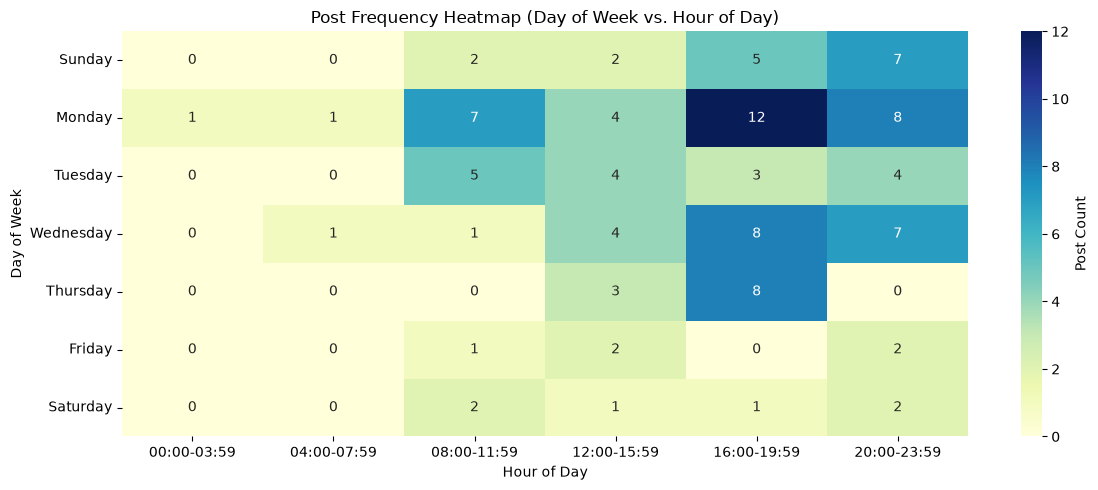

In [ ]:
df_datetime = df.dropna(subset=['posting_timestamp']).copy()

df_datetime['DayOfWeek'] = df_datetime['posting_timestamp'].dt.day_name()
labels = ['00:00-03:59', '04:00-07:59', '08:00-11:59', '12:00-15:59', '16:00-19:59', '20:00-23:59']

df_datetime['Hour_4H'] = pd.cut(
    df_datetime['posting_timestamp'].dt.hour, 
    bins=[-1, 3, 7, 11, 15, 19, 23], 
    labels=labels
)

day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

heatmap_data = pd.crosstab(
    df_datetime['DayOfWeek'], 
    df_datetime['Hour_4H']
).reindex(day_order)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', cbar_kws={'label': 'Post Count'})
plt.title('Post Frequency Heatmap (Day of Week vs. Hour of Day)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

Sunday has been shifted up to highlight the pattern visible in the data.

## Nominal variables

Nominal variables are such categorical variables where categories have no inherent order or ranking.
The univariate analysis here focuses on frequency distributions, central tendency (mode), and cardinality/entropy.

### survey_type

Just sanity checks, this variable here is not necessary from the point of view of the decision making. We expect it to be not null and constant everywhere; `survey_type='20 Days'`.

In [40]:
st = df['survey_type']
is_valid = (st.eq('20 Days')).all()
print(f'''
The variable survey_type is valid: {is_valid}
''')


The variable survey_type is valid: True



### department

Department the reposndent declared they belong to.

O - operacyjny; 
B - biznesowy; 
P - projektowy; 
T - techniczny

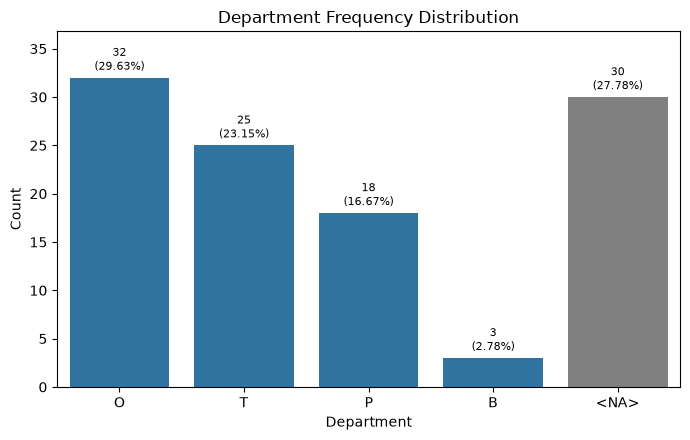

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

current_series = df['department']

total_obs = len(current_series)
freq_map = {}
for item in current_series:
    key = '<NA>' if item is None or (hasattr(item, 'isna') and item.isna()) or str(item) in ('nan', '<NA>') else str(item)
    freq_map[key] = freq_map.get(key, 0) + 1

na_count = freq_map.pop('<NA>', 0)

sorted_valid = sorted(freq_map.items(), key=lambda x: x[1], reverse=True)
categories = [k for k, _ in sorted_valid] + ['<NA>']
counts = [v for _, v in sorted_valid] + [na_count]

fig, ax = plt.subplots(figsize=(7, 4.5))

palette = ['gray' if cat == '<NA>' else 'tab:blue' for cat in categories]

sns.barplot(
    x=categories,
    y=counts,
    hue=categories,
    legend=False,
    ax=ax,
    palette=palette
)

ax.set_title('Department Frequency Distribution')
ax.set_xlabel('Department')
ax.set_ylabel('Count')

for container in ax.containers:
    labels = [f'{int(v)}\n({v/total_obs:.2%})' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.show()

In [58]:
mode_key, mode_val = sorted_valid[0]
antimode_key, antimode_val = sorted_valid[-1]

print(f'''
The mode category is "{mode_key}" with value {mode_val}, constituting therefore {mode_val/total_obs:.2%} of all observations.
The antimode category is "{antimode_key}" with value {antimode_val}, constituting therefore {antimode_val/total_obs:.2%} of all observations.
There are {na_count} answer{'s' if na_count != 1 else ''} with no department specified, constituting therefore {na_count/total_obs:.2%} of all observations.
''')


The mode category is "O" with value 32, constituting therefore 29.63% of all observations.
The antimode category is "B" with value 3, constituting therefore 2.78% of all observations.
There are 30 answers with no department specified, constituting therefore 27.78% of all observations.



## Ordinal variables

### onboarding_rating

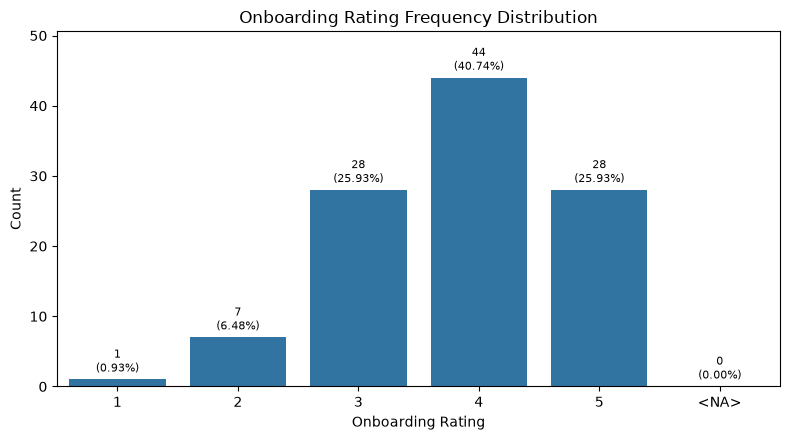

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

current_series = df['onboarding_rating']
total_obs = len(current_series)
ordinal_order = list(current_series.dtype.categories)

freq_map = {}
for item in current_series:
    key = '<NA>' if item is None or (hasattr(item, 'isna') and item.isna()) or str(item) in ('nan', '<NA>') else str(item)
    freq_map[key] = freq_map.get(key, 0) + 1

categories = [str(cat) for cat in ordinal_order] + ['<NA>']
counts = [freq_map.get(cat, 0) for cat in categories]

fig, ax = plt.subplots(figsize=(8, 4.5))

palette = ['gray' if cat == '<NA>' else 'tab:blue' for cat in categories]

sns.barplot(
    x=categories,
    y=counts,
    hue=categories,
    legend=False,
    ax=ax,
    palette=palette
)

ax.set_title('Onboarding Rating Frequency Distribution')
ax.set_xlabel('Onboarding Rating')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    labels = [f'{int(v)}\n({v/total_obs:.2%})' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

ax.set_ylim(0, max(counts, default=1) * 1.15)

plt.tight_layout()
plt.show()

In [105]:
*ordered_valid, na_counter = list(zip(categories, counts))
na_count = na_counter[1]
average_score = sum(int(cat) * count for (cat, count) in ordered_valid)/total_obs
median_score = current_series.cat.codes[current_series.cat.codes >= 0].median()
mode_key, mode_val = max(ordered_valid, key=lambda x: x[1])
antimode_key, antimode_val = min(ordered_valid, key=lambda x: x[1])


print(f'''
The average score is "{average_score:.2f}".
The median score is "{int(median_score) if int(median_score) == median_score else median_score}".
The mode score is "{mode_key}" with value {mode_val}, constituting therefore {mode_val/total_obs:.2%} of all observations.
The antimode score is "{antimode_key}" with value {antimode_val}, constituting therefore {antimode_val/total_obs:.2%} of all observations.
There are {na_count} answer{'s' if na_count != 1 else ''} with no department specified, constituting therefore {na_count/total_obs:.2%} of all observations.
''')

average_score


The average score is "3.84".
The median score is "3".
The mode score is "4" with value 44, constituting therefore 40.74% of all observations.
The antimode score is "1" with value 1, constituting therefore 0.93% of all observations.
There are 0 answers with no department specified, constituting therefore 0.00% of all observations.



3.8425925925925926

onboarding_rating	positive_feedback	negative_feedback	positive_feedback_EN	negative_feedback_EN	positive_feedback_EN_neg	positive_feedback_EN_neu	positive_feedback_EN_pos	positive_feedback_EN_compound	negative_feedback_EN_neg	negative_feedback_EN_neu	negative_feedback_EN_pos	negative_feedback_EN_compound